In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.svm import LinearSVC
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)

print("Libraries loaded successfully")



Libraries loaded successfully


## 1. Load and Explore the Dataset



In [2]:
BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
DATA_PATH = BASE_DIR / "Dataset" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df_raw = pd.read_csv(DATA_PATH)

print(f"Shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head()



Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("=== Data Types ===")
print(df_raw.dtypes)

print("\n=== Missing Values Reported by pandas ===")
print(df_raw.isnull().sum())

print("\n=== Churn Distribution ===")
print(df_raw["Churn"].value_counts())
print(df_raw["Churn"].value_counts(normalize=True).round(4))



=== Data Types ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== Missing Values Reported by pandas ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contra

## Preprocessing



In [4]:
X_raw = df_raw.drop(columns=["customerID", "Churn"]).copy()
X_raw["TotalCharges"] = pd.to_numeric(X_raw["TotalCharges"], errors="coerce")
y = df_raw["Churn"].map({"No": 0, "Yes": 1})

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

numeric_columns = X_train_raw.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X_train_raw.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_columns,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            drop="first",
                            handle_unknown="ignore",
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            categorical_columns,
        ),
    ],
    verbose_feature_names_out=False,
)

X_train_array = preprocessor.fit_transform(X_train_raw)
X_test_array = preprocessor.transform(X_test_raw)
feature_names = preprocessor.get_feature_names_out()

X_train = pd.DataFrame(
    X_train_array,
    columns=feature_names,
    index=X_train_raw.index,
)
X_test = pd.DataFrame(
    X_test_array,
    columns=feature_names,
    index=X_test_raw.index,
)

# Do not scale SeniorCitizen because it is a binary indicator.
CONTINUOUS_COLUMNS = ["tenure", "MonthlyCharges", "TotalCharges"]

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}")
print(f"Test churn rate: {y_test.mean():.3f}")
print(f"Number of encoded features: {X_train.shape[1]}")



Train size: (5634, 30)
Test size: (1409, 30)
Train churn rate: 0.265
Test churn rate: 0.265
Number of encoded features: 30


## 3. Helper Functions



In [5]:
REGULARIZED_SVM_PARAMS = {
    "C": 1.0,
    "class_weight": "balanced",
    "dual": False,
    "max_iter": 10000,
}


def get_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
    }


def run_svm(X_tr, X_te, y_tr, y_te, **kwargs):
    model_params = {
        **REGULARIZED_SVM_PARAMS,
        **kwargs,
    }

    model = LinearSVC(
        random_state=42,
        **model_params,
    )
    model.fit(X_tr, y_tr)

    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)
    test_score = model.decision_function(X_te)

    return {
        "model": model,
        "train_accuracy": accuracy_score(y_tr, train_pred),
        "y_pred": test_pred,
        "y_prob": test_score,
        "metrics": get_metrics(y_te, test_pred, test_score),
    }


def print_result(title, result):
    test_accuracy = result["metrics"]["Accuracy"]

    print(f"=== {title} ===")
    print(f"Train Accuracy: {result['train_accuracy']:.4f}")
    print(f"Test Accuracy : {test_accuracy:.4f}")
    print(f"Accuracy Gap  : {result['train_accuracy'] - test_accuracy:.4f}")

    for metric, value in result["metrics"].items():
        print(f"{metric:<12}: {value:.4f}")


def plot_metrics_bar(results, title, figsize=(10, 4)):
    labels = list(results.keys())
    metric_names = list(next(iter(results.values())).keys())
    x = np.arange(len(metric_names))
    width = 0.8 / len(labels)

    fig, ax = plt.subplots(figsize=figsize)

    for index, (label, metrics) in enumerate(results.items()):
        values = [metrics[name] for name in metric_names]
        bars = ax.bar(
            x + index * width,
            values,
            width,
            label=label,
            alpha=0.85,
        )

        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    ax.set_xticks(x + width * (len(labels) - 1) / 2)
    ax.set_xticklabels(metric_names)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_confusion(y_true, y_pred, title):
    matrix = confusion_matrix(y_true, y_pred)
    display = ConfusionMatrixDisplay(
        matrix,
        display_labels=["No Churn", "Churn"],
    )

    fig, ax = plt.subplots(figsize=(4.5, 4))
    display.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_roc(roc_data, title):
    fig, ax = plt.subplots(figsize=(6, 5))

    for label, (false_positive_rate, true_positive_rate, auc_value) in roc_data.items():
        ax.plot(
            false_positive_rate,
            true_positive_rate,
            linewidth=2,
            label=f"{label} (AUC={auc_value:.3f})",
        )

    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


print("Helper functions defined for SVM")


Helper functions defined for SVM


## Scenario 1 - Baseline Regularized SVM


In [6]:
baseline_result = run_svm(
    X_train,
    X_test,
    y_train,
    y_test,
    C=1.0,
)

print_result("Scenario 1 - Baseline Regularized SVM", baseline_result)
print()
print(
    classification_report(
        y_test,
        baseline_result["y_pred"],
        target_names=["No Churn", "Churn"],
    )
)



=== Scenario 1 - Baseline Regularized SVM ===
Train Accuracy: 0.7474
Test Accuracy : 0.7360
Accuracy Gap  : 0.0114
Accuracy    : 0.7360
Precision   : 0.5017
Recall      : 0.7941
F1-Score    : 0.6149
ROC-AUC     : 0.8402

              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



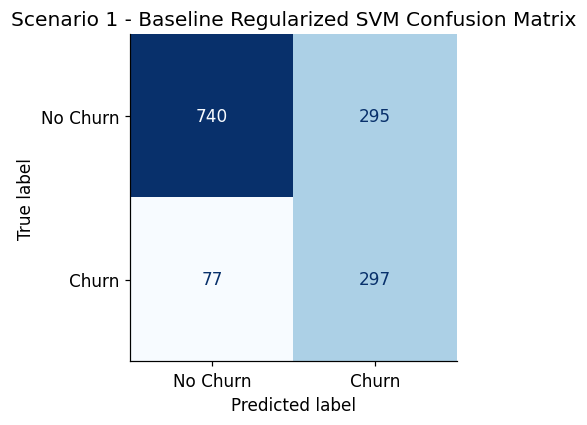

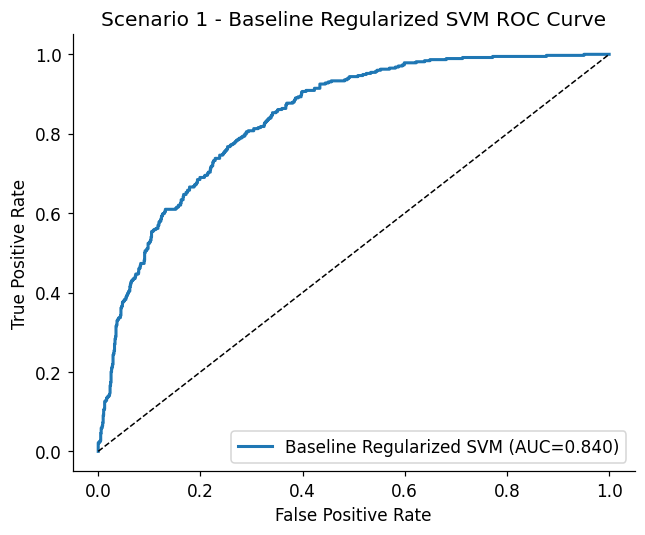

In [7]:
plot_confusion(
    y_test,
    baseline_result["y_pred"],
    "Scenario 1 - Baseline Regularized SVM Confusion Matrix",
)

baseline_fpr, baseline_tpr, _ = roc_curve(
    y_test,
    baseline_result["y_prob"],
)
plot_roc(
    {
        "Baseline Regularized SVM": (
            baseline_fpr,
            baseline_tpr,
            baseline_result["metrics"]["ROC-AUC"],
        )
    },
    "Scenario 1 - Baseline Regularized SVM ROC Curve",
)



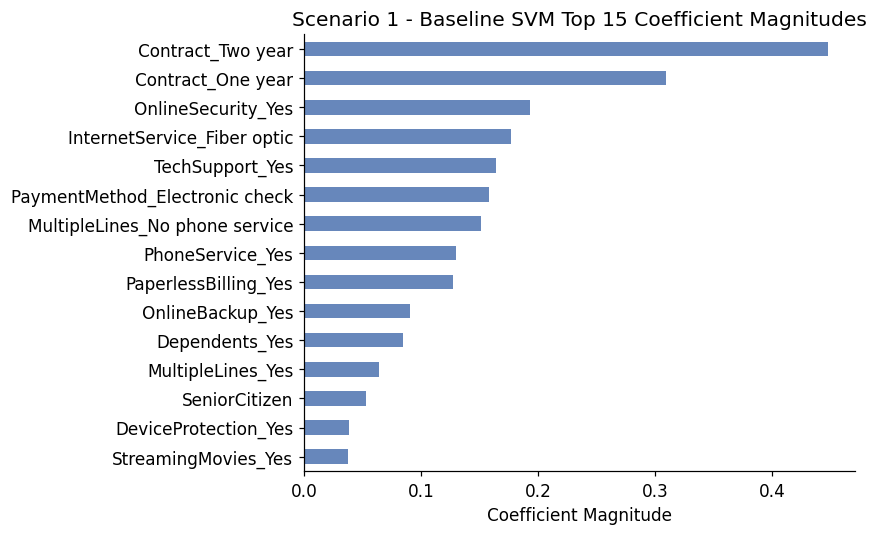

In [8]:
baseline_importance = pd.Series(
    np.abs(baseline_result["model"].coef_).ravel(),
    index=X_train.columns,
)
top_15_baseline_features = baseline_importance.nlargest(15)

fig, ax = plt.subplots(figsize=(8, 5))
top_15_baseline_features.sort_values().plot(
    kind="barh",
    ax=ax,
    color="#4C72B0",
    alpha=0.85,
)
ax.set_title("Scenario 1 - Baseline SVM Top 15 Coefficient Magnitudes")
ax.set_xlabel("Coefficient Magnitude")
plt.tight_layout()
plt.show()



## Scenario 2 - Feature Scaling Comparison



In [9]:
no_scaling_result = run_svm(
    X_train,
    X_test,
    y_train,
    y_test,
    C=1.0,
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[CONTINUOUS_COLUMNS] = scaler.fit_transform(
    X_train[CONTINUOUS_COLUMNS]
)
X_test_scaled[CONTINUOUS_COLUMNS] = scaler.transform(
    X_test[CONTINUOUS_COLUMNS]
)

scaling_result = run_svm(
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    C=1.0,
)

print_result("Scenario 2A - No Scaling", no_scaling_result)
print()
print_result("Scenario 2B - StandardScaler", scaling_result)



=== Scenario 2A - No Scaling ===
Train Accuracy: 0.7474
Test Accuracy : 0.7360
Accuracy Gap  : 0.0114
Accuracy    : 0.7360
Precision   : 0.5017
Recall      : 0.7941
F1-Score    : 0.6149
ROC-AUC     : 0.8402

=== Scenario 2B - StandardScaler ===
Train Accuracy: 0.7460
Test Accuracy : 0.7374
Accuracy Gap  : 0.0086
Accuracy    : 0.7374
Precision   : 0.5034
Recall      : 0.7861
F1-Score    : 0.6138
ROC-AUC     : 0.8387


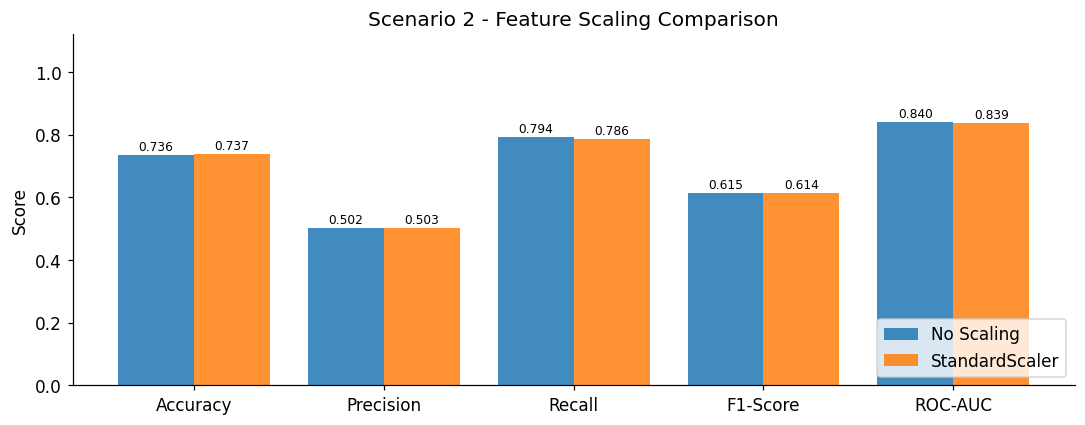

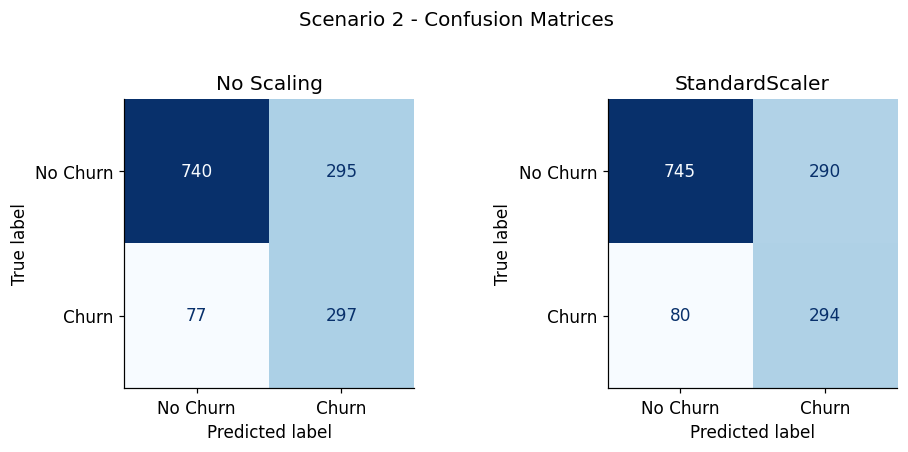

In [10]:
scenario_2_metrics = {
    "No Scaling": no_scaling_result["metrics"],
    "StandardScaler": scaling_result["metrics"],
}

plot_metrics_bar(
    scenario_2_metrics,
    "Scenario 2 - Feature Scaling Comparison",
)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, (label, result) in zip(
    axes,
    [
        ("No Scaling", no_scaling_result),
        ("StandardScaler", scaling_result),
    ],
):
    matrix = confusion_matrix(y_test, result["y_pred"])
    display = ConfusionMatrixDisplay(
        matrix,
        display_labels=["No Churn", "Churn"],
    )
    display.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(label)

plt.suptitle("Scenario 2 - Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()



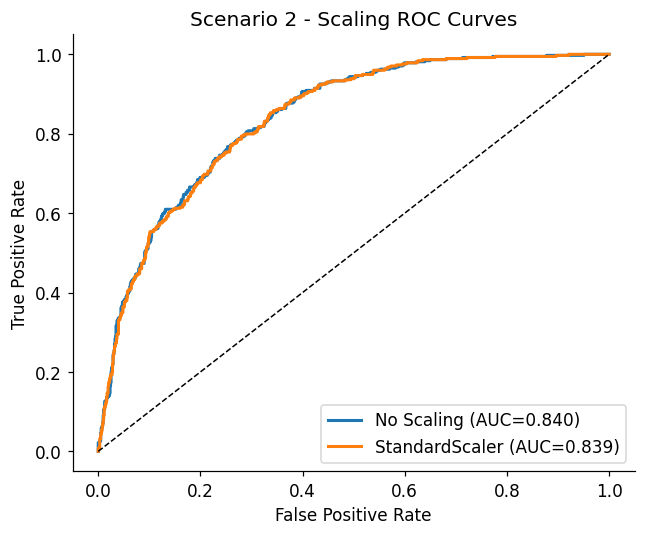

In [11]:
scenario_2_roc = {}

for label, result in [
    ("No Scaling", no_scaling_result),
    ("StandardScaler", scaling_result),
]:
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        result["y_prob"],
    )
    scenario_2_roc[label] = (
        false_positive_rate,
        true_positive_rate,
        result["metrics"]["ROC-AUC"],
    )

plot_roc(
    scenario_2_roc,
    "Scenario 2 - Scaling ROC Curves",
)



In [12]:
print("=== Scenario 2 Metric Differences: Scaling - No Scaling ===")

for metric in no_scaling_result["metrics"]:
    difference = (
        scaling_result["metrics"][metric]
        - no_scaling_result["metrics"][metric]
    )
    print(f"{metric:<12}: {difference:+.4f}")

print("\nComparison complete.")


=== Scenario 2 Metric Differences: Scaling - No Scaling ===
Accuracy    : +0.0014
Precision   : +0.0017
Recall      : -0.0080
F1-Score    : -0.0011
ROC-AUC     : -0.0014

Comparison complete.


## Scenario 3 - Required `C` Comparison

- `C=0.5`
- `C=1.0`
- `C=2.0`



In [13]:
c_values = [0.5, 1.0, 2.0]
scenario_3_results = {}

for c_value in c_values:
    label = f"C={c_value}"
    scenario_3_results[label] = run_svm(
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test,
        C=c_value,
    )

print(
    f"{'Model':<10}"
    f"{'Train Acc':>12}"
    f"{'Test Acc':>12}"
    f"{'Gap':>10}"
    f"{'F1':>10}"
    f"{'ROC-AUC':>10}"
)
print("-" * 64)

for label, result in scenario_3_results.items():
    train_accuracy = result["train_accuracy"]
    test_accuracy = result["metrics"]["Accuracy"]

    print(
        f"{label:<10}"
        f"{train_accuracy:>12.4f}"
        f"{test_accuracy:>12.4f}"
        f"{train_accuracy - test_accuracy:>10.4f}"
        f"{result['metrics']['F1-Score']:>10.4f}"
        f"{result['metrics']['ROC-AUC']:>10.4f}"
    )


Model        Train Acc    Test Acc       Gap        F1   ROC-AUC
----------------------------------------------------------------
C=0.5           0.7464      0.7381    0.0082    0.6152    0.8391
C=1.0           0.7460      0.7374    0.0086    0.6138    0.8387
C=2.0           0.7458      0.7381    0.0077    0.6152    0.8385


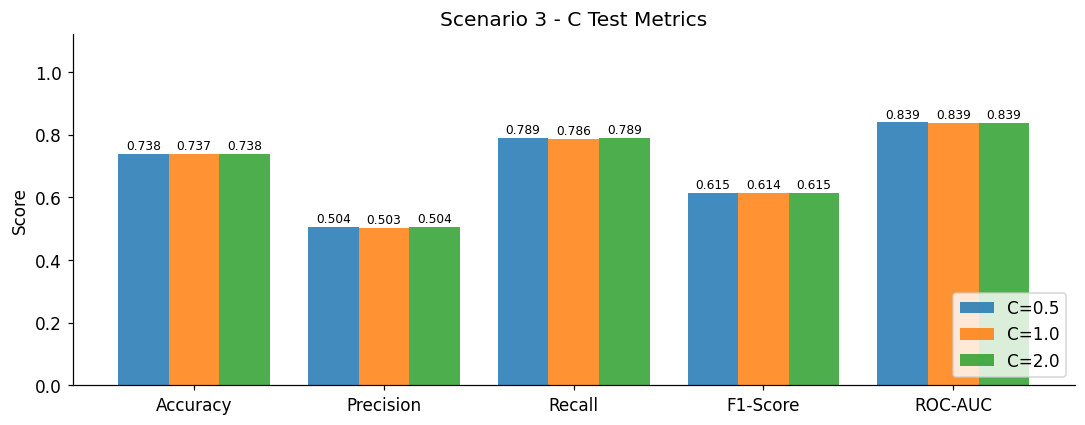

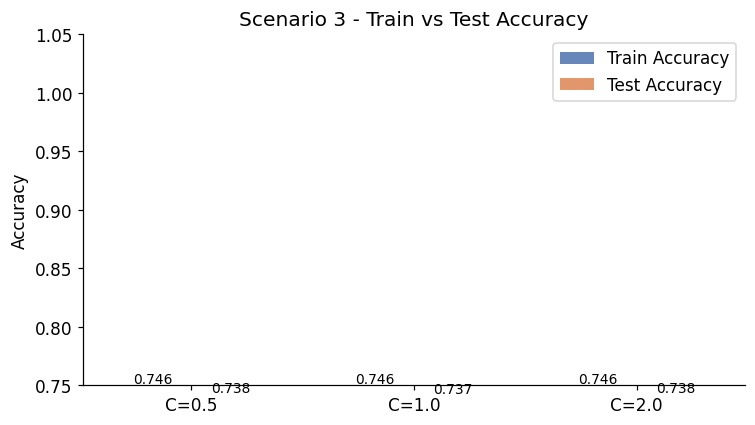

In [14]:
plot_metrics_bar(
    {
        label: result["metrics"]
        for label, result in scenario_3_results.items()
    },
    "Scenario 3 - C Test Metrics",
)

labels = list(scenario_3_results)
train_accuracies = [
    result["train_accuracy"]
    for result in scenario_3_results.values()
]
test_accuracies = [
    result["metrics"]["Accuracy"]
    for result in scenario_3_results.values()
]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
train_bars = ax.bar(
    x - width / 2,
    train_accuracies,
    width,
    label="Train Accuracy",
    color="#4C72B0",
    alpha=0.85,
)
test_bars = ax.bar(
    x + width / 2,
    test_accuracies,
    width,
    label="Test Accuracy",
    color="#DD8452",
    alpha=0.85,
)

for bars in [train_bars, test_bars]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.75, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Scenario 3 - Train vs Test Accuracy")
ax.legend()
plt.tight_layout()
plt.show()



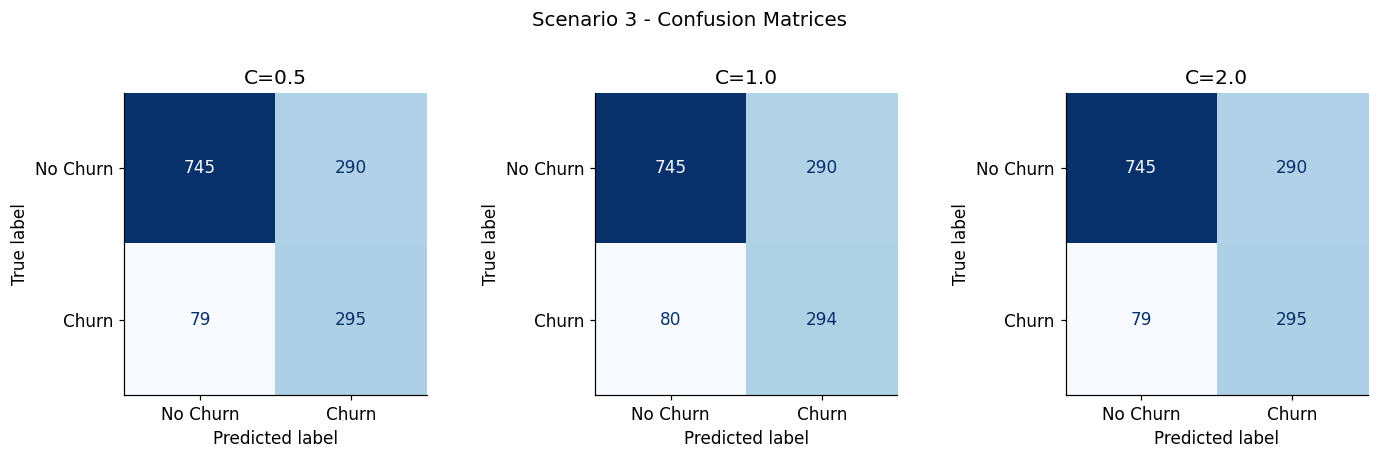

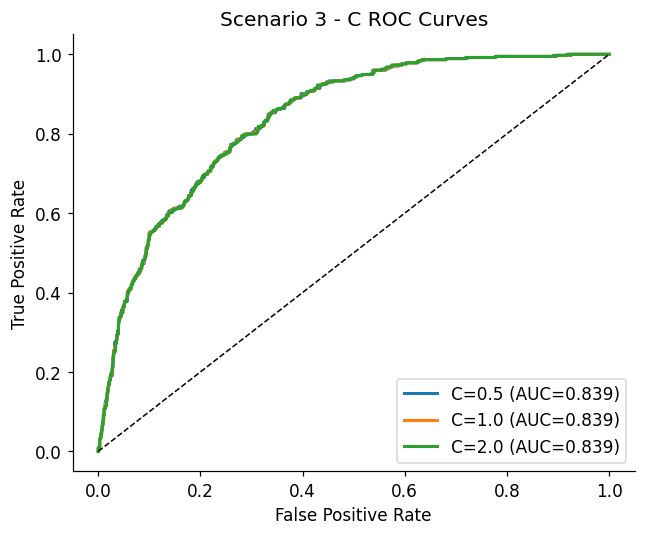

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (label, result) in zip(axes, scenario_3_results.items()):
    matrix = confusion_matrix(y_test, result["y_pred"])
    display = ConfusionMatrixDisplay(
        matrix,
        display_labels=["No Churn", "Churn"],
    )
    display.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(label)

plt.suptitle("Scenario 3 - Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

scenario_3_roc = {}

for label, result in scenario_3_results.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        result["y_prob"],
    )
    scenario_3_roc[label] = (
        false_positive_rate,
        true_positive_rate,
        result["metrics"]["ROC-AUC"],
    )

plot_roc(
    scenario_3_roc,
    "Scenario 3 - C ROC Curves",
)



## Summary



In [16]:
all_results = {
    "S1 - Baseline Regularized SVM": baseline_result["metrics"],
    "S2A - No Scaling": no_scaling_result["metrics"],
    "S2B - Scaling": scaling_result["metrics"],
}

for label, result in scenario_3_results.items():
    all_results[f"S3 - {label}"] = result["metrics"]

summary_df = pd.DataFrame(all_results).T.round(4)
print(summary_df.to_string())



                               Accuracy  Precision  Recall  F1-Score  ROC-AUC
S1 - Baseline Regularized SVM    0.7360     0.5017  0.7941    0.6149   0.8402
S2A - No Scaling                 0.7360     0.5017  0.7941    0.6149   0.8402
S2B - Scaling                    0.7374     0.5034  0.7861    0.6138   0.8387
S3 - C=0.5                       0.7381     0.5043  0.7888    0.6152   0.8391
S3 - C=1.0                       0.7374     0.5034  0.7861    0.6138   0.8387
S3 - C=2.0                       0.7381     0.5043  0.7888    0.6152   0.8385


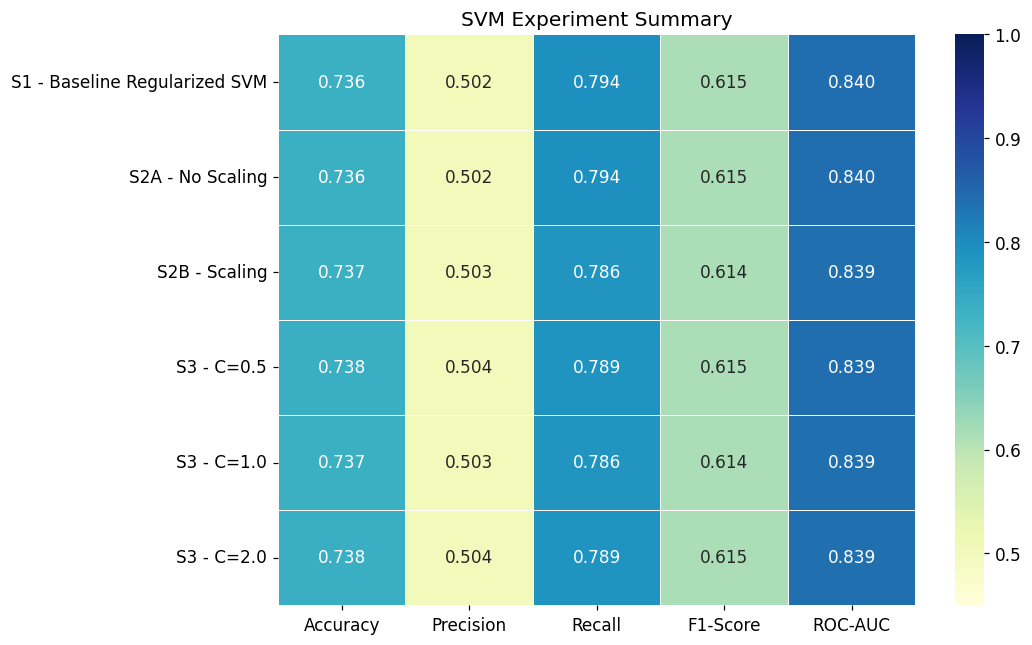

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    summary_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax,
    vmin=0.45,
    vmax=1.0,
)
ax.set_title("SVM Experiment Summary")
plt.tight_layout()
plt.show()

